#  Amazon Product Review Sentiment Analysis (NLP Project)

##  Objective
To build a sentiment analysis model using Natural Language Processing (NLP) techniques that classifies Amazon product reviews as Positive or Negative.

##  Key Steps:
Data Cleaning
Tokenization
Stopword Removal
Lemmatization
Bag of Words (BoW)
TF-IDF Feature Engineering
Model Training (Logistic Regression & Naive Bayes)
Model Evaluation

# Import Libraries

In [21]:
import pandas as pd
import numpy as np
import re
import nltk

In [22]:
import os
os.listdir()

['Lemmatization.ipynb',
 'nl-basics.ipynb',
 'Reviews.csv',
 'Stemming.ipynb',
 'Stopwords.ipynb',
 'Tokenization.ipynb']

# Loading Dataset

In [23]:
data = pd.read_csv("Reviews.csv", encoding='latin-1')
data = data.sample(50000, random_state=42)
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
165256,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
231465,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
427827,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
433954,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
70260,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...


# Data Explaination
Checking dataset structure and missing values.

In [24]:
data.info()

<class 'pandas.DataFrame'>
Index: 50000 entries, 165256 to 469239
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Id                      50000 non-null  int64
 1   ProductId               50000 non-null  str  
 2   UserId                  50000 non-null  str  
 3   ProfileName             50000 non-null  str  
 4   HelpfulnessNumerator    50000 non-null  int64
 5   HelpfulnessDenominator  50000 non-null  int64
 6   Score                   50000 non-null  int64
 7   Time                    50000 non-null  int64
 8   Summary                 49999 non-null  str  
 9   Text                    50000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 4.2 MB


In [25]:
data.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
dtype: int64

Text column has no missing values
Dataset is suitable for NLP processing

## Handling Missing Values
Remove rows where 'Text' is missing.

In [28]:
data = data.dropna(subset=['Text'])

# Score Distribution

Analyze rating distribution.

In [30]:
data['Score'].value_counts()

Score
5    32097
4     7008
1     4528
2     2576
Name: count, dtype: int64

Majority of reviews are positive
Dataset is imbalanced

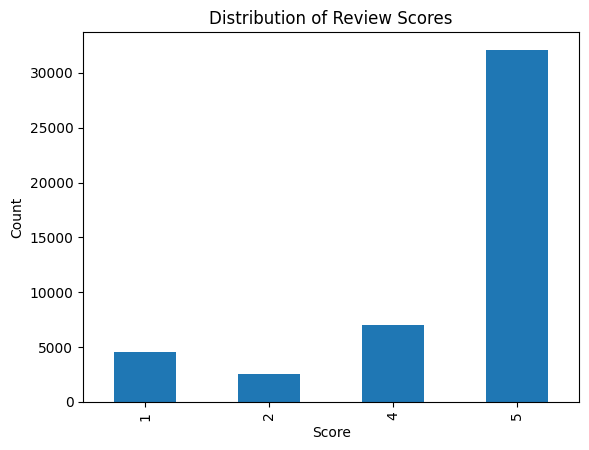

In [66]:
import matplotlib.pyplot as plt

data['Score'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

This graph shows that most reviews are rated 4 and 5, indicating that the dataset is skewed towards positive sentiment.

## Sentiment Conversion
Convert (Score) ratings into binary sentiment.

In [31]:
def convert_sentiment(score):
    if score <= 2:
        return 0   # Negative
    elif score == 3:
        return None  # Neutral (remove)
    else:
        return 1   # Positive

data['sentiment'] = data['Score'].apply(convert_sentiment)

# Remove neutral values
data = data.dropna(subset=['sentiment'])

Binary classification created
Neutral reviews removed

In [32]:
data['sentiment'].value_counts()

sentiment
1    39105
0     7104
Name: count, dtype: int64

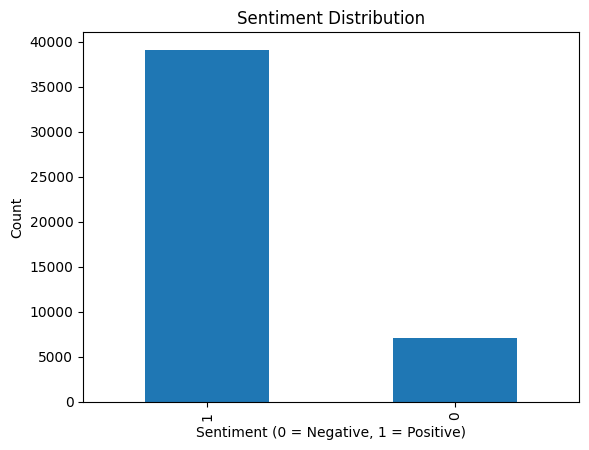

In [67]:
data['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

This visualization confirms that the dataset is imbalanced, with significantly more positive reviews than negative ones.”

## NLP Setup
Download required for NLP resources.

In [33]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [34]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

## Tokenization
Split text into words.

In [46]:
import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize

sample = data['Text'].iloc[0]
print(word_tokenize(sample))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['Having', 'tried', 'a', 'couple', 'of', 'other', 'brands', 'of', 'gluten-free', 'sandwich', 'cookies', ',', 'these', 'are', 'the', 'best', 'of', 'the', 'bunch', '.', 'They', "'re", 'crunchy', 'and', 'true', 'to', 'the', 'texture', 'of', 'the', 'other', '``', 'real', "''", 'cookies', 'that', 'are', "n't", 'gluten-free', '.', 'Some', 'might', 'think', 'that', 'the', 'filling', 'makes', 'them', 'a', 'bit', 'too', 'sweet', ',', 'but', 'for', 'me', 'that', 'just', 'means', 'I', "'ve", 'satisfied', 'my', 'sweet', 'tooth', 'sooner', '!', 'The', 'chocolate', 'version', 'from', 'Glutino', 'is', 'just', 'as', 'good', 'and', 'has', 'a', 'true', '``', 'chocolatey', "''", 'taste', '-', 'something', 'that', 'is', "n't", 'there', 'with', 'the', 'other', 'gluten-free', 'brands', 'out', 'there', '.']


## Text Cleaning
Perform:
- Lowercasing
- Removing special characters
- Tokenization
- Stopword removal
- Lemmatization

In [47]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return " ".join(words)

## Apply Cleaning

In [48]:
data['cleaned_text'] = data['Text'].apply(clean_text)
data[['Text', 'cleaned_text']].head()

,Text,cleaned_text
165256,Having tried a couple of other brands of glute...,tried couple brand gluten free sandwich cooky ...
231465,My cat loves these treats. If ever I can't fin...,cat love treat ever find house pop top bolt wh...
433954,"First there was Frosted Mini-Wheats, in origin...",first frosted mini wheat original size frosted...
70260,and I want to congratulate the graphic artist ...,want congratulate graphic artist putting entir...
49866,Please add more Pineapple flavor to your packa...,please add pineapple flavor package lifesaver ...


Text got cleaned and normalized and ready for feature extraction

## Bag of Words (BoW)
Convert text into word frequency vectors.

In [49]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(data['cleaned_text'])
y = data['sentiment']

# Train-Test Split (BoW)

In [50]:
from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

## Naive Bayes with BoW

In [51]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

bow_model = MultinomialNB()
bow_model.fit(X_train_bow, y_train_bow)

y_pred_bow = bow_model.predict(X_test_bow)

bow_acc = accuracy_score(y_test_bow, y_pred_bow)
print("BoW Accuracy:", bow_acc)

BoW Accuracy: 0.9006708504652673


## TF-IDF Vectorization (Term Frequency - Inverse Document Frequency)
Convert text using weighted importance.

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_tfidf = tfidf.fit_transform(data['cleaned_text'])
y = data['sentiment']

## Train-Test Split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression (TF-IDF)

In [59]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9162518935295391


# Model Evaluation

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9162518935295391

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.52      0.64      1345
           1       0.92      0.98      0.95      7897

    accuracy                           0.92      9242
   macro avg       0.88      0.75      0.80      9242
weighted avg       0.91      0.92      0.91      9242



# Confusion Matrix

In [61]:
confusion_matrix(y_test,y_pred)

array([[ 701,  644],
       [ 130, 7767]])

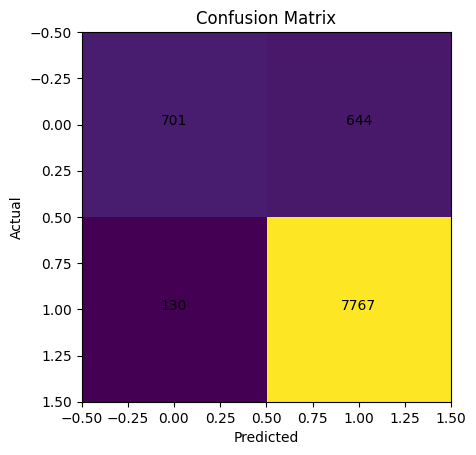

In [68]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center')

plt.show()

This heatmap shows how many predictions were correct and incorrect. The diagonal values represent correct predictions, while off-diagonal values indicate errors.

## Naive Bayes (TF-IDF)

In [55]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.8824929668902834


## Model Comparison

| Model | Accuracy |
|------|---------|
| BoW + Naive Bayes | (bow_acc) |
| TF-IDF + Logistic Regression | (lr_acc) |
| TF-IDF + Naive Bayes | (nb_acc) |

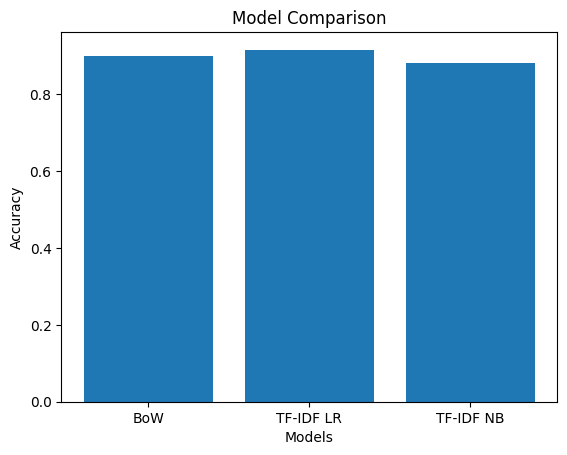

In [69]:
models = ['BoW', 'TF-IDF LR', 'TF-IDF NB']
scores = [bow_acc, lr_acc, nb_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

### Final Conclusion

TF-IDF performs better than Bag of Words
Naive Bayes works well for text classification
Logistic Regression also provides strong performance
Text preprocessing significantly improves model accuracy

### Key Learning:
NLP pipeline is crucial before model training
Feature engineering (TF-IDF) is the most impactful step

## Prediction Function

In [56]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    prediction = nb_model.predict(vector)[0]
    
    return "Positive" if prediction == 1 else "Negative"

# Testing

In [57]:
predict_sentiment("This product is amazing!")
predict_sentiment("Worst product ever")

'Positive'